# Hate Speech Detection using RNN, LSTM, and Word2Vec Embeddings
**Module:** 6CS012 – Artificial Intelligence and Machine Learning  
**Task:** Part III – Language Tasks  
**Dataset:** Hate Speech and Offensive Language Dataset (`hatevsoffensive_language.csv`)

## 0. Environment Setup and GPU Check

In [1]:
# Import TensorFlow library
import tensorflow as tf

# Print the installed TensorFlow version
print("TensorFlow version:", tf.__version__)

# Detect available GPU devices
gpus = tf.config.list_physical_devices('GPU')

# Display the list of detected GPUs
print("GPUs available:", gpus)

# Check if at least one GPU is available
if gpus:
    # Enable dynamic memory allocation for the first GPU
    # This prevents TensorFlow from using all GPU memory at once
    tf.config.experimental.set_memory_growth(gpus[0], True)

    # Confirmation message
    print("GPU memory growth enabled.")
else:
    # Message shown when no GPU is detected
    print("No GPU found. Running on CPU. Enable GPU in Runtime > Change runtime type.")

TensorFlow version: 2.20.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU memory growth enabled.


In [2]:
# Install Gensim for topic modeling and NLP tasks
!pip install gensim -q

# Install NLTK for text processing and linguistic tools
!pip install nltk -q

# Install WordCloud for text visualization
!pip install wordcloud -q

# Install Contractions to expand shortened words like "don't" → "do not"
!pip install contractions -q

# Install Gradio for creating interactive web interfaces
!pip install gradio -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.3 MB/s eta 0:00:00


In [3]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import re
import string
import time
import warnings
from collections import Counter
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Contractions
import contractions

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

# Keras / TensorFlow
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM, Dense,
                                      Dropout, BatchNormalization, Bidirectional)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# Wordcloud
from wordcloud import WordCloud

print("All imports successful.")

All imports successful.


## 1. Data Loading and Understanding

In [4]:
# ── UPLOAD DATASET DIRECTLY IN COLAB ─────────────────────────────────────────
# Click the "Choose Files" button that appears below and select your CSV file.
from google.colab import files
import io

uploaded = files.upload()          # triggers the file picker

filename = list(uploaded.keys())[0]
print(f"Uploaded: {filename}")

df_raw = pd.read_csv(io.BytesIO(uploaded[filename]))

print("=== Dataset Shape ===")
print(df_raw.shape)
print("\n=== Columns ===")
print(df_raw.columns.tolist())
print("\n=== First 3 Rows ===")
df_raw.head(3)

Saving hatevsoffensive_language.csv to hatevsoffensive_language.csv
Uploaded: hatevsoffensive_language.csv
=== Dataset Shape ===
(24783, 2)

=== Columns ===
['label', 'text']

=== First 3 Rows ===


,label,text
0,neither,!!! RT @mayasolovely: As a woman you shouldn't...
1,offensive language,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,offensive language,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...


In [13]:
# ── SELECT & RENAME RELEVANT COLUMNS ──────────────────────────────────────────
# Handles both 'tweet' and 'text' column names
text_col = 'tweet' if 'tweet' in df_raw.columns else 'text'
df = df_raw[['label', text_col]].copy()
df.columns = ['label', 'text']

# Drop duplicates and nulls
df.drop_duplicates(subset='text', inplace=True)
df.dropna(subset=['text', 'label'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Dataset shape after deduplication: {df.shape}")
print("\nLabel distribution (raw):")
print(df['label'].value_counts())
print("\nSample rows:")
df.head(3)

Dataset shape after deduplication: (24783, 2)

Label distribution (raw):
label
offensive language    19190
neither                4163
hate speec             1430
Name: count, dtype: int64

Sample rows:


,label,text
0,neither,!!! RT @mayasolovely: As a woman you shouldn't...
1,offensive language,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,offensive language,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...


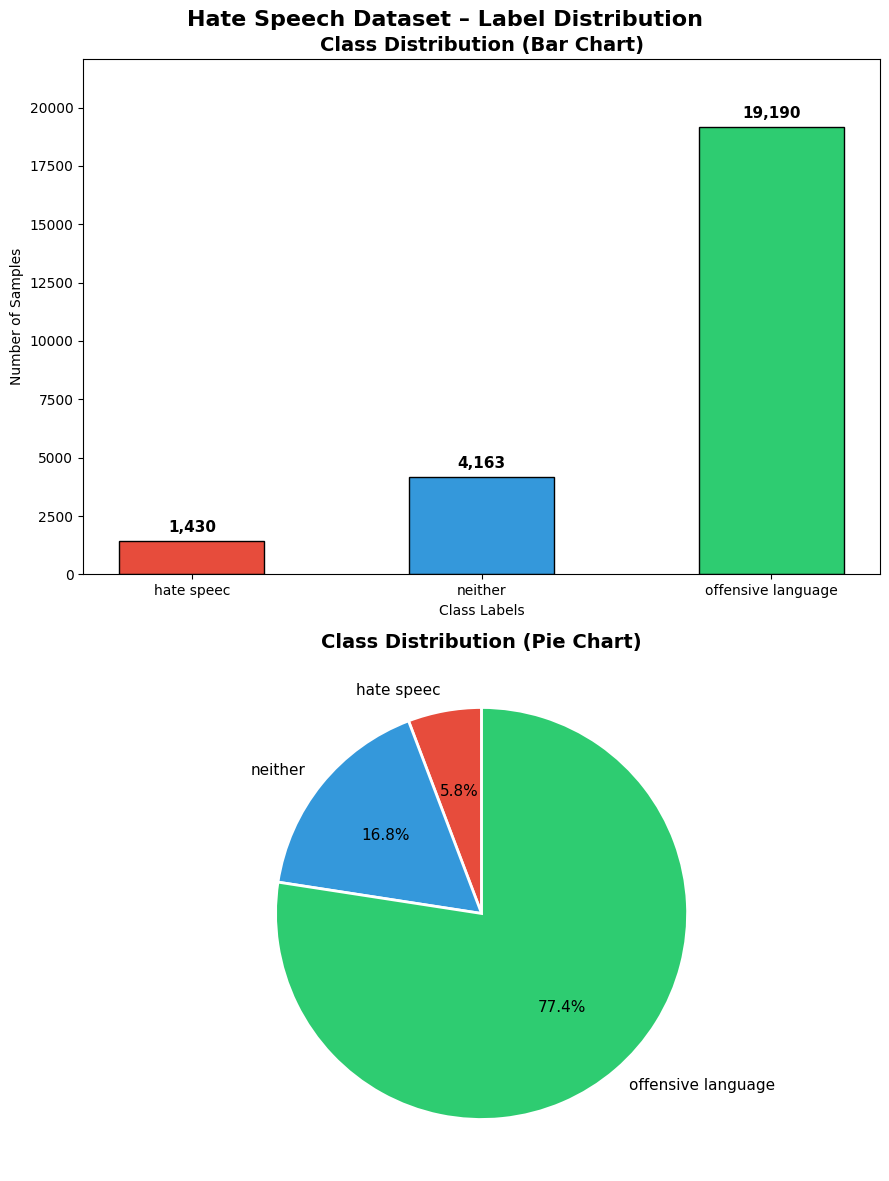

Note: Dataset is imbalanced – class weights will be applied during training.


In [15]:
# ── CLASS DISTRIBUTION VISUALIZATION ─────────────────────────────────────────

# Count labels in dataset
label_counts = df['label'].value_counts().sort_index()

# Convert numeric labels into readable names
label_name_map = {
    0: 'Hate Speech',
    1: 'Offensive',
    2: 'Neither'
}

readable_labels = [
    label_name_map.get(l, str(l))
    for l in label_counts.index
]

# Define colors for plots
bar_colors = ['#e74c3c', '#3498db', '#2ecc71']

# Create vertical layout (Up & Down)
fig, axes = plt.subplots(2, 1, figsize=(9, 12))

# ── BAR CHART ────────────────────────────────────────────────────────────────
bars = axes[0].bar(
    readable_labels,
    label_counts.values,
    color=bar_colors[:len(label_counts)],
    edgecolor='black',
    width=0.5
)

axes[0].set_title(
    'Class Distribution (Bar Chart)',
    fontsize=14,
    fontweight='bold'
)

axes[0].set_xlabel('Class Labels')
axes[0].set_ylabel('Number of Samples')

# Add count labels above bars
axes[0].set_ylim(0, label_counts.max() * 1.15)

for bar, value in zip(bars, label_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + label_counts.max() * 0.02,
        f'{value:,}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

# ── PIE CHART ────────────────────────────────────────────────────────────────
wedge_props = {
    'edgecolor': 'white',
    'linewidth': 2
}

axes[1].pie(
    label_counts.values,
    labels=readable_labels,
    autopct='%1.1f%%',
    colors=bar_colors[:len(label_counts)],
    startangle=90,
    wedgeprops=wedge_props,
    textprops={'fontsize': 11}
)

axes[1].set_title(
    'Class Distribution (Pie Chart)',
    fontsize=14,
    fontweight='bold'
)

# Main title
plt.suptitle(
    'Hate Speech Dataset – Label Distribution',
    fontsize=16,
    fontweight='bold'
)

# Adjust spacing
plt.tight_layout()

# Save figure
plt.savefig(
    'class_distribution.png',
    dpi=150,
    bbox_inches='tight'
)

# Show plots
plt.show()

# Dataset imbalance note
print("Note: Dataset is imbalanced – class weights will be applied during training.")

In [16]:
# ── TWEET LENGTH ANALYSIS (before cleaning) ──────────────────────────────────
df['raw_length'] = df['text'].apply(lambda x: len(str(x).split()))

print("Tweet length statistics by class (word count):")
print(df.groupby('label')['raw_length'].describe().round(2))



Tweet length statistics by class (word count):
                      count   mean   std  min  25%   50%   75%   max
label                                                               
hate speec           1430.0  13.91  7.04  1.0  8.0  13.5  20.0  32.0
neither              4163.0  14.92  6.80  1.0  9.0  15.0  20.0  52.0
offensive language  19190.0  13.96  6.80  1.0  8.0  13.0  19.0  36.0


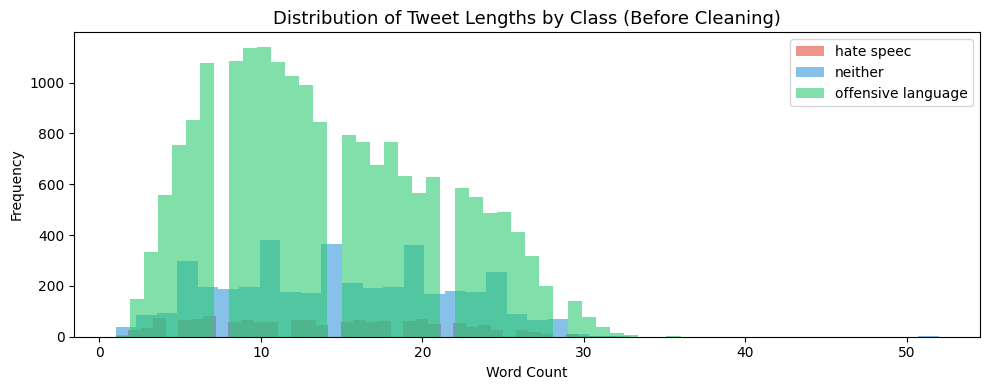

In [17]:
#Histogram
plt.figure(figsize=(10, 4))
for i, label in enumerate(sorted(df['label'].unique())):
    subset = df[df['label'] == label]['raw_length']
    name   = label_name_map.get(label, str(label))
    plt.hist(subset, bins=40, alpha=0.6, label=name, color=bar_colors[i % 3])
plt.title('Distribution of Tweet Lengths by Class (Before Cleaning)', fontsize=13)
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('text_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Text Preprocessing

Preprocessing steps applied in order:
1. **Remove RT prefix** – `RT @user:` appears at the start of every retweet and adds no signal  
2. Lowercase  
3. Expand contractions (`don't` → `do not`)  
4. Remove URLs, @mentions, #hashtags  
5. Remove HTML entities and non-alphabetic characters  
6. Lemmatize, remove stopwords (keeping negations)

In [18]:
# ── SETUP LEMMATIZER & STOPWORDS ─────────────────────────────────────────────
lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

# Keep negation words – critical for hate/offensive detection
keep_negations = {'no', 'not', 'nor', 'neither', 'never', 'nobody', 'nothing', 'nowhere'}
stop_words = stop_words - keep_negations

# ── CLEAN TEXT FUNCTION ───────────────────────────────────────────────────────
def clean_text(text):
    text = str(text)

    # Step 1 – Remove retweet prefix (RT @username:)
    # This pattern matches: optional leading whitespace + "RT" + @anything + colon
    text = re.sub(r'^\s*RT\s+@\w+:\s*', '', text, flags=re.IGNORECASE)
    # Also catch bare "rt" at start without @
    text = re.sub(r'^\s*rt\b\s*', '', text, flags=re.IGNORECASE)

    # Step 2 – Lowercase
    text = text.lower()

    # Step 3 – Expand contractions (do before removing punctuation)
    text = contractions.fix(text)

    # Step 4 – Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Step 5 – Remove @mentions
    text = re.sub(r'@\w+', '', text)

    # Step 6 – Remove #hashtags
    text = re.sub(r'#\w+', '', text)

    # Step 7 – Remove HTML entities
    text = re.sub(r'&amp;|&lt;|&gt;|&quot;', ' ', text)
    text = re.sub(r'&#\d+;', '', text)

    # Step 8 – Keep only alphabetic characters and spaces
    text = re.sub(r'[^a-z\s]', '', text)

    # Step 9 – Normalise whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 10 – Tokenise, remove stopwords, lemmatise
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words and len(w) > 1]

    return ' '.join(tokens)

print("Cleaning tweets...")
df['cleaned_text'] = df['text'].apply(clean_text)

# Remove rows where cleaning produced an empty string
before = len(df)
df = df[df['cleaned_text'].str.strip().astype(bool)].reset_index(drop=True)
after = len(df)
print(f"Done. Removed {before - after} empty rows after cleaning.")
print(f"Final dataset size: {after:,}")

# ── SHOW BEFORE / AFTER (with RT example) ─────────────────────────────────────
rt_examples = df[df['text'].str.startswith('RT', na=False)].head(3)
other_examples = df[~df['text'].str.startswith('RT', na=False)].head(2)
examples = pd.concat([rt_examples, other_examples])

print("\n=== Before / After Cleaning ===")
for _, row in examples.iterrows():
    print(f"  ORIGINAL : {row['text'][:90]}")
    print(f"  CLEANED  : {row['cleaned_text'][:90]}")
    print()

Cleaning tweets...
Done. Removed 20 empty rows after cleaning.
Final dataset size: 24,763

=== Before / After Cleaning ===
  ORIGINAL : RT !! @6oysLoveKeena: I will never EVER EVER give a nigga my all unless I know for a fact 
  CLEANED  : never ever ever give nigga unless know fact yeen fixing play bitch

  ORIGINAL : RT "@DestineyDunbar: This shit for the birds . &#128530;&#8221;
  CLEANED  : shit bird

  ORIGINAL : RT "@HuffingtonPost: Jane Seymour rocks a bikini at 62 http://t.co/1pUccv8t97" Crazy Aunt 
  CLEANED  : jane seymour rock bikini crazy aunt jane

  ORIGINAL : !!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp
  CLEANED  : rt woman not complain cleaning house man always take trash

  ORIGINAL : !!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!
  CLEANED  : rt boy dat coldtyga dwn bad cuffin dat hoe st place



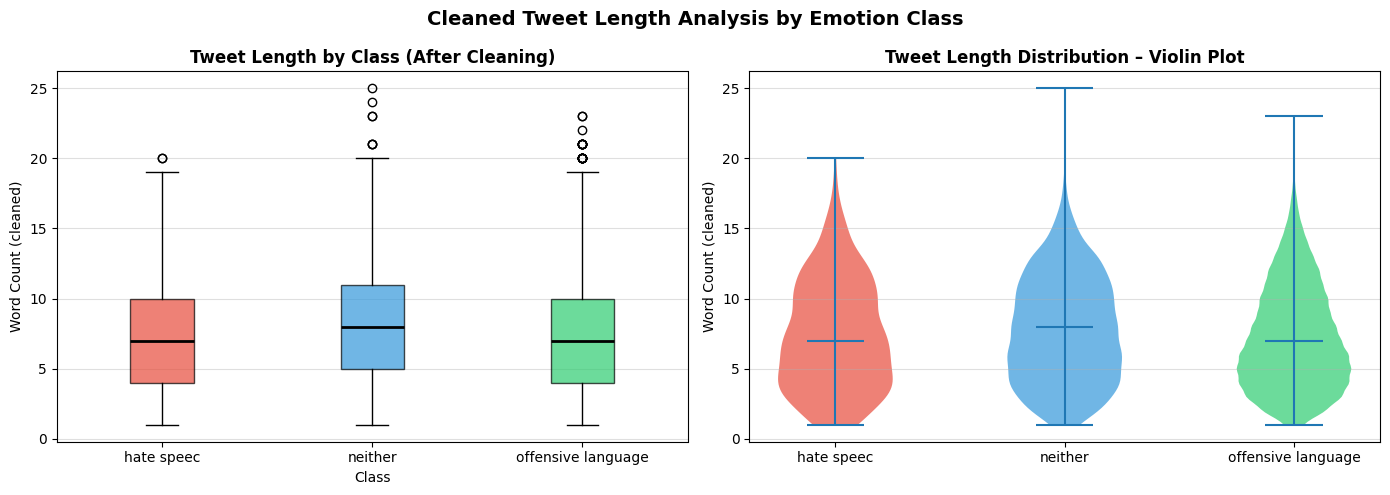

Insight: Hate speech tweets tend to be shorter; offensive language tweets are longer.


In [19]:
# ── TEXT LENGTH DISTRIBUTION PER CLASS (replaces word cloud) ─────────────────
# Shows how long tweets are in each class — clean, informative, no raw words.
df['clean_len'] = df['cleaned_text'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot — spread of tweet lengths per class
class_data  = [df[df['label'] == l]['clean_len'].values
               for l in sorted(df['label'].unique())]
readable_lb = [label_name_map.get(l, str(l)) for l in sorted(df['label'].unique())]

bp = axes[0].boxplot(class_data, labels=readable_lb, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
colors_box = ['#e74c3c', '#3498db', '#2ecc71']
for patch, col in zip(bp['boxes'], colors_box):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)
axes[0].set_title('Tweet Length by Class (After Cleaning)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Word Count (cleaned)')
axes[0].grid(axis='y', alpha=0.4)

# Violin plot — full distribution shape
parts = axes[1].violinplot(class_data, showmedians=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors_box[i])
    pc.set_alpha(0.7)
axes[1].set_xticks([1, 2, 3])
axes[1].set_xticklabels(readable_lb)
axes[1].set_title('Tweet Length Distribution – Violin Plot', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Word Count (cleaned)')
axes[1].grid(axis='y', alpha=0.4)

plt.suptitle('Cleaned Tweet Length Analysis by Emotion Class',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('tweet_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Insight: Hate speech tweets tend to be shorter; offensive language tweets are longer.")

=== Vocabulary Statistics per Class ===
             Class  Total Words  Unique Words  Avg Length  Lexical Diversity (TTR)
        hate speec        10508          3073         7.4                    0.292
           neither        32285          8274         7.8                    0.256
offensive language       138378         13863         7.2                    0.100


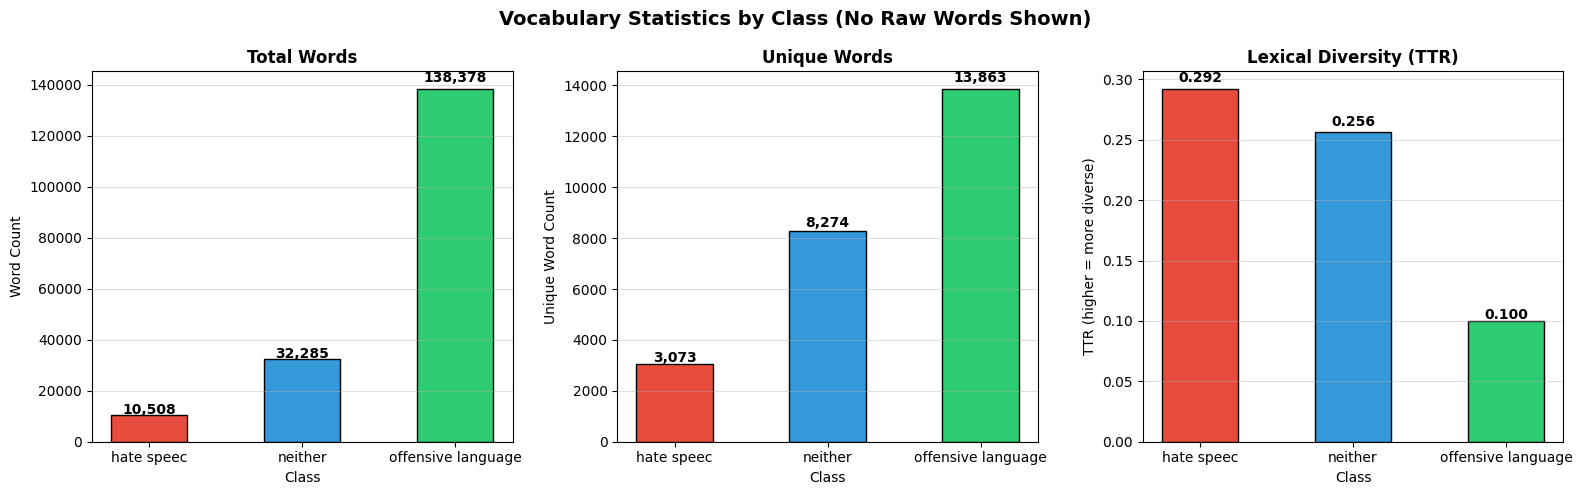

TTR = Type-Token Ratio: proportion of unique words (lexical richness).


In [20]:
# ── UNIQUE WORD COVERAGE PER CLASS (replaces top-20 word bar chart) ──────────
# Shows vocabulary statistics per class — informative without displaying words.
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf  = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
tfidf.fit(df['cleaned_text'])

stats_rows = []
for label in sorted(df['label'].unique()):
    subset  = df[df['label'] == label]['cleaned_text']
    words   = ' '.join(subset).split()
    unique  = len(set(words))
    total   = len(words)
    avg_len = subset.apply(lambda x: len(str(x).split())).mean()
    ttr     = unique / total if total > 0 else 0   # Type-Token Ratio (lexical diversity)
    name    = label_name_map.get(label, str(label))
    stats_rows.append({'Class': name, 'Total Words': total,
                       'Unique Words': unique, 'Avg Length': round(avg_len, 1),
                       'Lexical Diversity (TTR)': round(ttr, 3)})

stats_df = pd.DataFrame(stats_rows)
print("=== Vocabulary Statistics per Class ===")
print(stats_df.to_string(index=False))

# ── VISUALISE VOCABULARY STATS ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['Total Words', 'Unique Words', 'Lexical Diversity (TTR)']
ylabels = ['Word Count', 'Unique Word Count', 'TTR (higher = more diverse)']
colors_bar = ['#e74c3c', '#3498db', '#2ecc71']

for ax, metric, ylabel in zip(axes, metrics, ylabels):
    bars = ax.bar(stats_df['Class'], stats_df[metric],
                  color=colors_bar[:len(stats_df)], edgecolor='black', width=0.5)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('Class')
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.4)
    for bar, v in zip(bars, stats_df[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.02,
                f'{v:,}' if metric != 'Lexical Diversity (TTR)' else f'{v:.3f}',
                ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Vocabulary Statistics by Class (No Raw Words Shown)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('vocab_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print("TTR = Type-Token Ratio: proportion of unique words (lexical richness).")

## 3. Tokenization, Encoding and Padding

In [11]:
# ── LABEL ENCODING ────────────────────────────────────────────────────────────
le = LabelEncoder()
df['encoded_label'] = le.fit_transform(df['label'])
num_classes = len(le.classes_)
print(f"Classes  : {le.classes_} → encoded as {list(range(num_classes))}")
print(f"Num classes: {num_classes}")

# One-hot encoding for categorical cross-entropy
y = to_categorical(df['encoded_label'], num_classes=num_classes)
print(f"y shape  : {y.shape}")

Classes  : ['hate speec' 'neither' 'offensive language'] → encoded as [0, 1, 2]
Num classes: 3
y shape  : (24763, 3)


In [12]:
# ── TRAIN / TEST SPLIT (80 / 20, stratified) ─────────────────────────────────
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['cleaned_text'].values, y,
    test_size=0.20, random_state=42,
    stratify=df['encoded_label']
)
print(f"Training samples : {len(X_train_text):,}")
print(f"Testing  samples : {len(X_test_text):,}")

Training samples : 19,810
Testing  samples : 4,953


In [13]:
# ── TOKENIZATION (fit on train only) ─────────────────────────────────────────
VOCAB_SIZE = 20000
tokenizer  = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_text)

word_index = tokenizer.word_index
print(f"Total unique tokens in training vocab: {len(word_index):,}")
print(f"Using top {VOCAB_SIZE:,} words (+ <OOV>)")

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq  = tokenizer.texts_to_sequences(X_test_text)

Total unique tokens in training vocab: 15,923
Using top 20,000 words (+ <OOV>)


In [42]:
# ── PADDING (95th-percentile length) ─────────────────────────────────────────
seq_lengths = [len(s) for s in X_train_seq]
MAX_LEN     = int(np.percentile(seq_lengths, 95))

print(f"Sequence length stats (train):")
print(f"  Mean : {np.mean(seq_lengths):.1f}")
print(f"  95th : {MAX_LEN}  ← used as MAX_LEN")
print(f"  Max  : {np.max(seq_lengths)}")

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')



Sequence length stats (train):
  Mean : 7.3
  95th : 14  ← used as MAX_LEN
  Max  : 24


In [43]:
print(f"\nX_train_pad shape : {X_train_pad.shape}")
print(f"X_test_pad  shape : {X_test_pad.shape}")


X_train_pad shape : (19810, 14)
X_test_pad  shape : (4953, 14)


In [15]:
# ── CLASS WEIGHTS (handle imbalance) ─────────────────────────────────────────
y_train_flat = np.argmax(y_train, axis=1)
cw_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_flat),
    y=y_train_flat
)
class_weight_dict = dict(enumerate(cw_arr))
print("Class weights applied during training:")
for cls_idx, w in class_weight_dict.items():
    cls_name = label_name_map.get(le.classes_[cls_idx], str(le.classes_[cls_idx]))
    print(f"  Class {cls_idx} ({cls_name}): {w:.3f}")

Class weights applied during training:
  Class 0 (hate speec): 5.792
  Class 1 (neither): 1.985
  Class 2 (offensive language): 0.430


## 4. Shared Callbacks and Helper Functions

In [16]:
# ── HYPERPARAMETERS ───────────────────────────────────────────────────────────
EMBEDDING_DIM = 64
EPOCHS        = 30
BATCH_SIZE    = 128

# ── CALLBACKS FACTORY ─────────────────────────────────────────────────────────
def get_callbacks():
    return [
        EarlyStopping(monitor='val_accuracy', patience=5,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-6, verbose=1),
    ]

# ── PLOT TRAINING HISTORY ─────────────────────────────────────────────────────
def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(history.history['loss'],     label='Train',      color='#e74c3c')
    axes[0].plot(history.history['val_loss'], label='Validation', color='#3498db', linestyle='--')
    axes[0].set_title(f'{model_name} – Loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Accuracy
    axes[1].plot(history.history['accuracy'],     label='Train',      color='#e74c3c')
    axes[1].plot(history.history['val_accuracy'], label='Validation', color='#3498db', linestyle='--')
    axes[1].set_title(f'{model_name} – Accuracy')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle(f'{model_name} – Training History', fontsize=14, fontweight='bold')
    plt.tight_layout()
    fname = model_name.replace(' ', '_').replace('–', '').replace('+', 'plus').strip('_')
    plt.savefig(f'{fname}_history.png', dpi=150, bbox_inches='tight')
    plt.show()

# ── EVALUATE MODEL ────────────────────────────────────────────────────────────
def evaluate_model(model, X_test, y_test, model_name, le):
    y_pred_prob = model.predict(X_test, batch_size=256, verbose=0)
    y_pred      = np.argmax(y_pred_prob, axis=1)
    y_true      = np.argmax(y_test,      axis=1)

    acc = accuracy_score(y_true, y_pred)
    print(f"\n{'='*55}")
    print(f"  {model_name}  |  Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"{'='*55}")

    # Use readable label names in report
    target_names = [label_name_map.get(c, str(c)) for c in le.classes_]
    print(classification_report(y_true, y_pred, target_names=target_names))

    # Confusion matrix
    cm_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f'{model_name} – Confusion Matrix', fontweight='bold')
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.tight_layout()
    fname = model_name.replace(' ', '_').replace('–', '').replace('+', 'plus').strip('_')
    plt.savefig(f'{fname}_cm.png', dpi=150, bbox_inches='tight')
    plt.show()

    return acc, y_pred, y_true

results     = {}
bar_colors  = ['#e74c3c', '#3498db', '#2ecc71']
print("Helpers ready.")

Helpers ready.


## 5. Model 1 – Simple RNN with Trainable Embedding

In [17]:
# ── BUILD MODEL 1 ─────────────────────────────────────────────────────────────
model1 = Sequential(name='SimpleRNN_Model')
model1.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM,
                     input_length=MAX_LEN, name='embedding_rnn'))
model1.add(Dropout(0.3))
model1.add(SimpleRNN(128, return_sequences=True))
model1.add(Dropout(0.3))
model1.add(SimpleRNN(64))
model1.add(Dense(64, activation='relu'))
model1.add(Dropout(0.3))
model1.add(Dense(num_classes, activation='softmax'))

model1.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Force build so summary shows full shapes and param counts
model1.build(input_shape=(None, MAX_LEN))
model1.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_rnn (Embedding)       │ (None, 14, 64)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 14, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,321,411 (5.04 MB)

 Trainable params: 1,321,411 (5.04 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# ── TRAIN MODEL 1 ─────────────────────────────────────────────────────────────
start = time.time()

history1 = model1.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    class_weight=class_weight_dict,
    callbacks=get_callbacks(),
    verbose=1
)

time1 = time.time() - start
print(f"\nModel 1 training time: {time1:.1f}s ({time1/60:.1f} min)")

Epoch 1/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.6117 - loss: 0.8747 - val_accuracy: 0.7924 - val_loss: 0.5982 - learning_rate: 0.0010
Epoch 2/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8024 - loss: 0.5152 - val_accuracy: 0.7974 - val_loss: 0.5745 - learning_rate: 0.0010
Epoch 3/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8556 - loss: 0.3542 - val_accuracy: 0.7934 - val_loss: 0.5387 - learning_rate: 0.0010
Epoch 4/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8879 - loss: 0.2558 - val_accuracy: 0.7389 - val_loss: 0.7700 - learning_rate: 0.0010
Epoch 5/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9097 - loss: 0.2017 - val_accuracy: 0.8301 - val_loss: 0.5165 - learning_rate: 0.0010
Epoch 6/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9299 - loss: 0.1557 - val_accuracy: 0.8412 - val_loss: 0.5396 - learning_rate: 0.0010
Epoch 7/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9350 - loss: 0.1326 

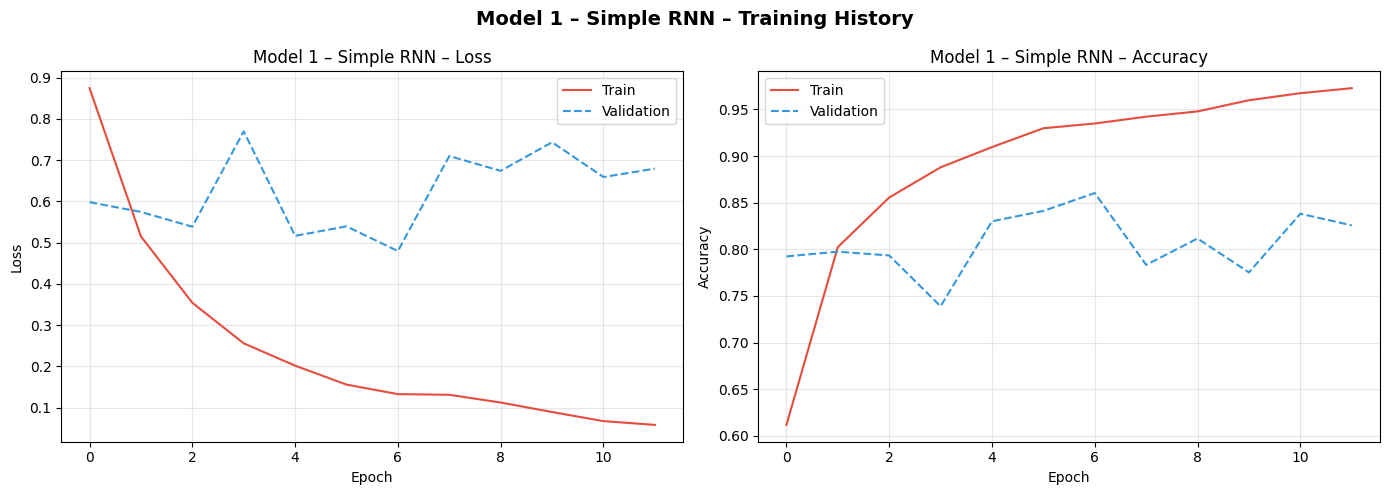


  Model 1 – Simple RNN  |  Test Accuracy: 0.8607 (86.07%)
                    precision    recall  f1-score   support

        hate speec       0.34      0.39      0.37       285
           neither       0.74      0.86      0.79       831
offensive language       0.94      0.90      0.92      3837

          accuracy                           0.86      4953
         macro avg       0.67      0.71      0.69      4953
      weighted avg       0.87      0.86      0.86      4953



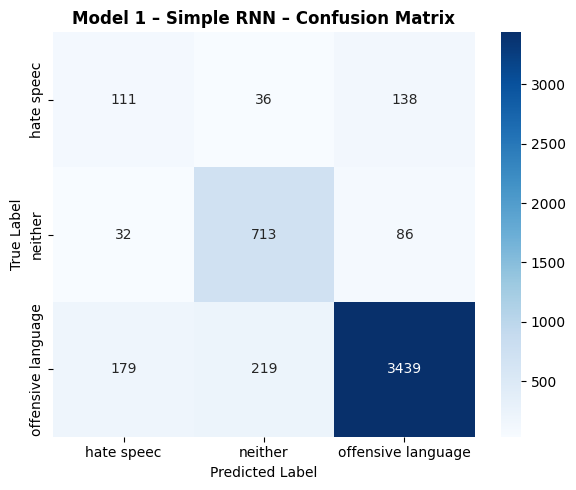

In [19]:
# ── EVALUATE MODEL 1 ──────────────────────────────────────────────────────────
plot_history(history1, 'Model 1 – Simple RNN')
acc1, pred1, true1 = evaluate_model(model1, X_test_pad, y_test,
                                    'Model 1 – Simple RNN', le)
results['SimpleRNN'] = {'accuracy': acc1, 'time': time1}

## 6. Model 2 – Bidirectional LSTM with Trainable Embedding

In [20]:
# ── BUILD MODEL 2 ─────────────────────────────────────────────────────────────
model2 = Sequential(name='LSTM_Model')
model2.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM,
                     input_length=MAX_LEN, name='embedding_lstm'))
model2.add(Dropout(0.3))
model2.add(Bidirectional(LSTM(128, return_sequences=True)))
model2.add(Dropout(0.3))
model2.add(Bidirectional(LSTM(64)))
model2.add(BatchNormalization())
model2.add(Dense(64, activation='relu'))
model2.add(Dropout(0.3))
model2.add(Dense(num_classes, activation='softmax'))

model2.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Force build so summary shows full shapes and param counts
model2.build(input_shape=(None, MAX_LEN))
model2.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_lstm (Embedding)      │ (None, 14, 64)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 14, 256)        │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,650,947 (6.30 MB)

 Trainable params: 1,650,691 (6.30 MB)

 Non-trainable params: 256 (1.00 KB)

In [21]:
# ── TRAIN MODEL 2 ─────────────────────────────────────────────────────────────
start = time.time()

history2 = model2.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    class_weight=class_weight_dict,
    callbacks=get_callbacks(),
    verbose=1
)

time2 = time.time() - start
print(f"\nModel 2 training time: {time2:.1f}s ({time2/60:.1f} min)")

Epoch 1/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.6842 - loss: 0.7379 - val_accuracy: 0.7786 - val_loss: 0.8152 - learning_rate: 0.0010
Epoch 2/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8071 - loss: 0.4222 - val_accuracy: 0.7742 - val_loss: 0.7610 - learning_rate: 0.0010
Epoch 3/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8634 - loss: 0.2807 - val_accuracy: 0.8287 - val_loss: 0.4905 - learning_rate: 0.0010
Epoch 4/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8963 - loss: 0.2073 - val_accuracy: 0.8405 - val_loss: 0.3992 - learning_rate: 0.0010
Epoch 5/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9191 - loss: 0.1644 - val_accuracy: 0.8015 - val_loss: 0.6774 - learning_rate: 0.0010
Epoch 6/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9255 - loss: 0.1440 - val_accuracy: 0.8479 - val_loss: 0.5103 - learning_rate: 0.0010
Epoch 7/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9470 - loss: 0

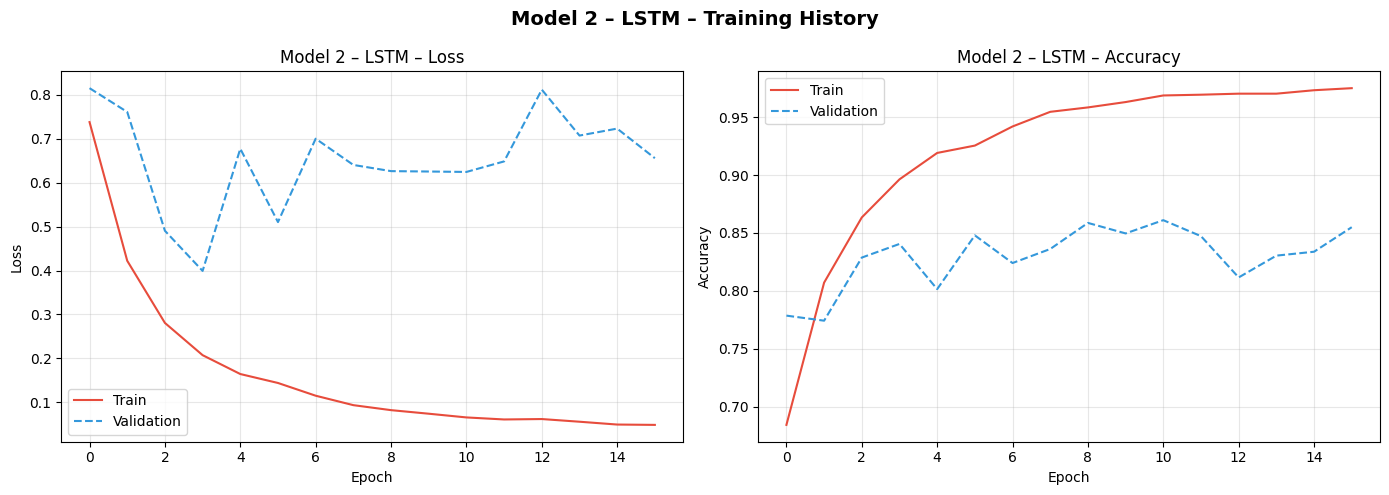


  Model 2 – LSTM  |  Test Accuracy: 0.8631 (86.31%)
                    precision    recall  f1-score   support

        hate speec       0.34      0.41      0.37       285
           neither       0.75      0.89      0.81       831
offensive language       0.94      0.89      0.92      3837

          accuracy                           0.86      4953
         macro avg       0.68      0.73      0.70      4953
      weighted avg       0.88      0.86      0.87      4953



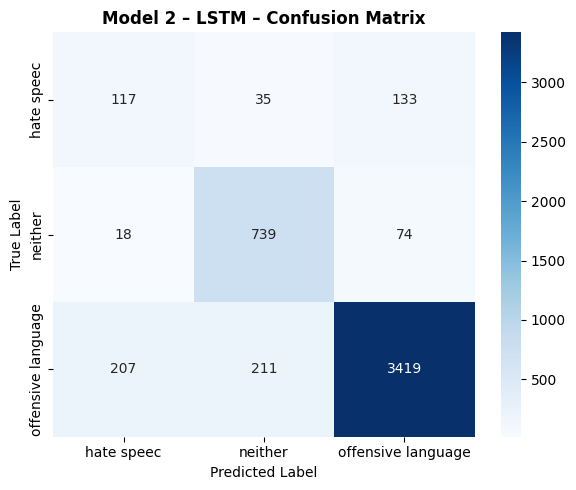

In [22]:
# ── EVALUATE MODEL 2 ──────────────────────────────────────────────────────────
plot_history(history2, 'Model 2 – LSTM')
acc2, pred2, true2 = evaluate_model(model2, X_test_pad, y_test,
                                    'Model 2 – LSTM', le)
results['LSTM'] = {'accuracy': acc2, 'time': time2}

## 7. Model 3 – Bidirectional LSTM with Pretrained GloVe Embeddings

In [23]:
# ── LOAD GloVe EMBEDDINGS (Twitter-trained – ideal for tweets) ────────────────
import gensim.downloader as api

print("Downloading GloVe Twitter embeddings (glove-twitter-50)...")
print("This may take a few minutes on first run.")
embedding_model = api.load('glove-twitter-50')
EMBED_DIM_W2V   = 50
print(f"GloVe model loaded. Vocabulary size: {len(embedding_model.key_to_index):,}")

This may take a few minutes on first run.
[==================================================] 100.0% 199.5/199.5MB downloaded
GloVe model loaded. Vocabulary size: 1,193,514


In [24]:
# ── BUILD EMBEDDING MATRIX ────────────────────────────────────────────────────
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM_W2V))
hits, misses = 0, 0

for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[idx] = embedding_model[word]
        hits += 1
    else:
        # Small random init for OOV words (better than zeros)
        embedding_matrix[idx] = np.random.normal(0, 0.1, EMBED_DIM_W2V)
        misses += 1

coverage = hits / (hits + misses) * 100
print(f"Vocabulary coverage: {coverage:.1f}%  ({hits:,} hits | {misses:,} misses)")

Vocabulary coverage: 85.1%  (13,550 hits | 2,373 misses)


In [25]:
# ── BUILD MODEL 3 ─────────────────────────────────────────────────────────────
model3 = Sequential(name='LSTM_GloVe_Model')
model3.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM_W2V,
                     weights=[embedding_matrix], input_length=MAX_LEN,
                     trainable=True, name='embedding_glove'))
model3.add(Dropout(0.3))
model3.add(Bidirectional(LSTM(128, return_sequences=True)))
model3.add(Dropout(0.3))
model3.add(Bidirectional(LSTM(64)))
model3.add(BatchNormalization())
model3.add(Dense(64, activation='relu'))
model3.add(Dropout(0.3))
model3.add(Dense(num_classes, activation='softmax'))

model3.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Force build so summary shows full shapes and param counts
model3.build(input_shape=(None, MAX_LEN))
model3.summary()

Model: "LSTM_GloVe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_glove (Embedding)     │ (None, 14, 50)         │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 14, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 14, 256)        │       183,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 14, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,356,611 (5.18 MB)

 Trainable params: 1,356,355 (5.17 MB)

 Non-trainable params: 256 (1.00 KB)

In [26]:
# ── TRAIN MODEL 3 ─────────────────────────────────────────────────────────────
start = time.time()

history3 = model3.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    class_weight=class_weight_dict,
    callbacks=get_callbacks(),
    verbose=1
)

time3 = time.time() - start
print(f"\nModel 3 training time: {time3:.1f}s ({time3/60:.1f} min)")

Epoch 1/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.5646 - loss: 0.9243 - val_accuracy: 0.7258 - val_loss: 0.8948 - learning_rate: 5.0000e-04
Epoch 2/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.6726 - loss: 0.7329 - val_accuracy: 0.8445 - val_loss: 0.6283 - learning_rate: 5.0000e-04
Epoch 3/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.7072 - loss: 0.6637 - val_accuracy: 0.6904 - val_loss: 0.6829 - learning_rate: 5.0000e-04
Epoch 4/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7348 - loss: 0.5947 - val_accuracy: 0.8382 - val_loss: 0.4363 - learning_rate: 5.0000e-04
Epoch 5/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7509 - loss: 0.5698 - val_accuracy: 0.8277 - val_loss: 0.4429 - learning_rate: 5.0000e-04
Epoch 6/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7715 - loss: 0.5192 - val_accuracy: 0.7372 - val_loss: 0.6039 - learning_rate: 5.0000e-04
Epoch 7/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - acc

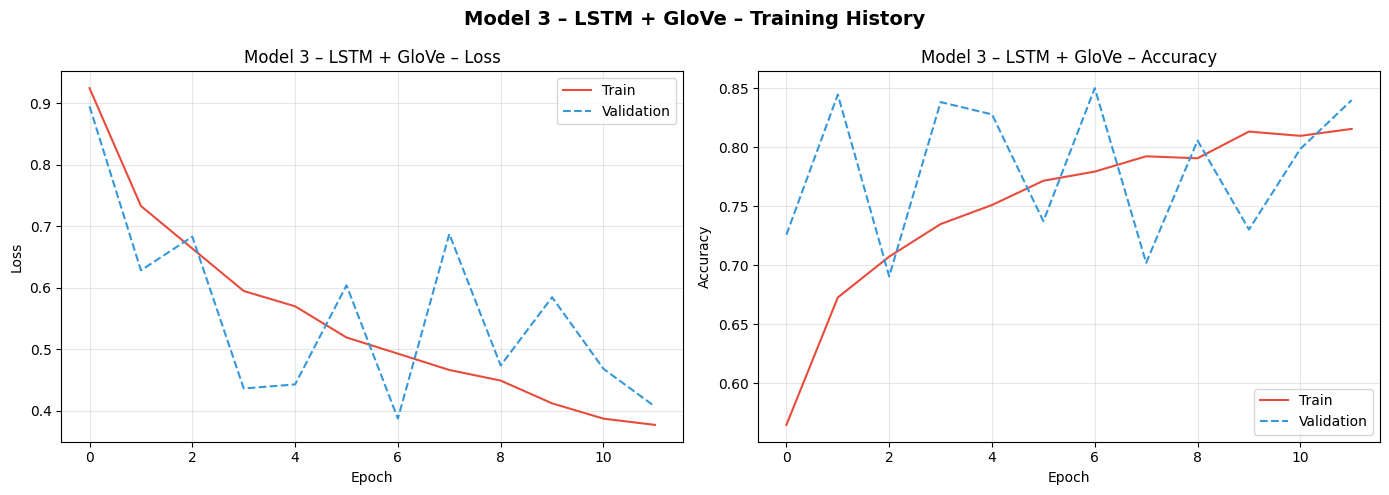


  Model 3 – LSTM + GloVe  |  Test Accuracy: 0.8587 (85.87%)
                    precision    recall  f1-score   support

        hate speec       0.34      0.56      0.42       285
           neither       0.74      0.93      0.82       831
offensive language       0.97      0.86      0.91      3837

          accuracy                           0.86      4953
         macro avg       0.68      0.79      0.72      4953
      weighted avg       0.89      0.86      0.87      4953



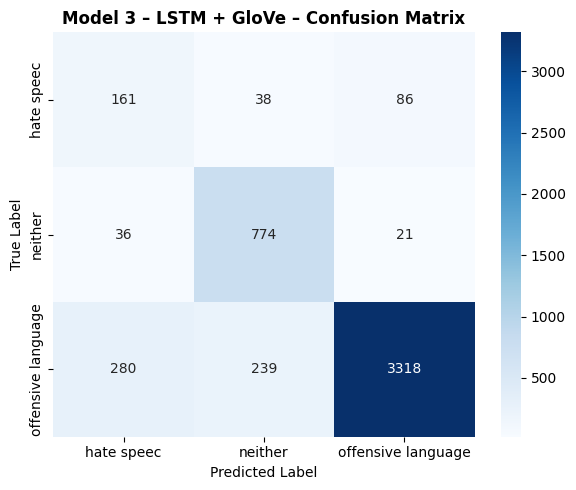

In [27]:
# ── EVALUATE MODEL 3 ──────────────────────────────────────────────────────────
plot_history(history3, 'Model 3 – LSTM + GloVe')
acc3, pred3, true3 = evaluate_model(model3, X_test_pad, y_test,
                                    'Model 3 – LSTM + GloVe', le)
results['LSTM_GloVe'] = {'accuracy': acc3, 'time': time3}

## 8. Comparative Analysis – All Models

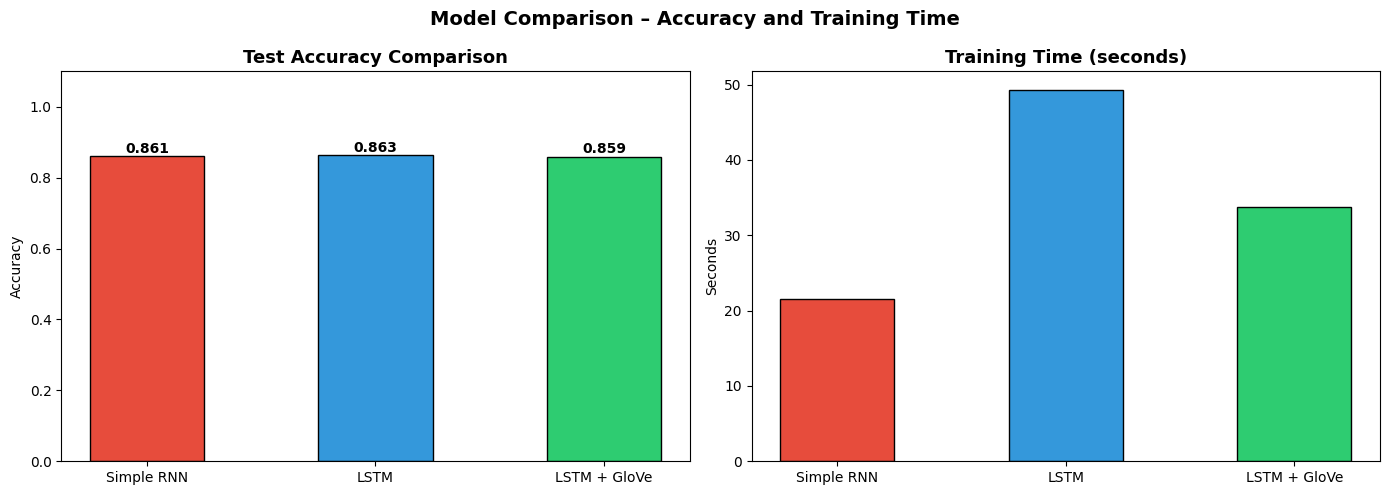

In [28]:
# ── ACCURACY & TIME BAR CHARTS ────────────────────────────────────────────────
model_names = ['Simple RNN', 'LSTM', 'LSTM + GloVe']
accuracies  = [results['SimpleRNN']['accuracy'],
               results['LSTM']['accuracy'],
               results['LSTM_GloVe']['accuracy']]
times_sec   = [results['SimpleRNN']['time'],
               results['LSTM']['time'],
               results['LSTM_GloVe']['time']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy bars
bars = axes[0].bar(model_names, accuracies, color=bar_colors, width=0.5, edgecolor='black')
axes[0].set_title('Test Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Accuracy')
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.01,
                 f'{acc:.3f}', ha='center', fontweight='bold')

# Training time bars
axes[1].bar(model_names, times_sec, color=bar_colors, width=0.5, edgecolor='black')
axes[1].set_title('Training Time (seconds)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Seconds')

plt.suptitle('Model Comparison – Accuracy and Training Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

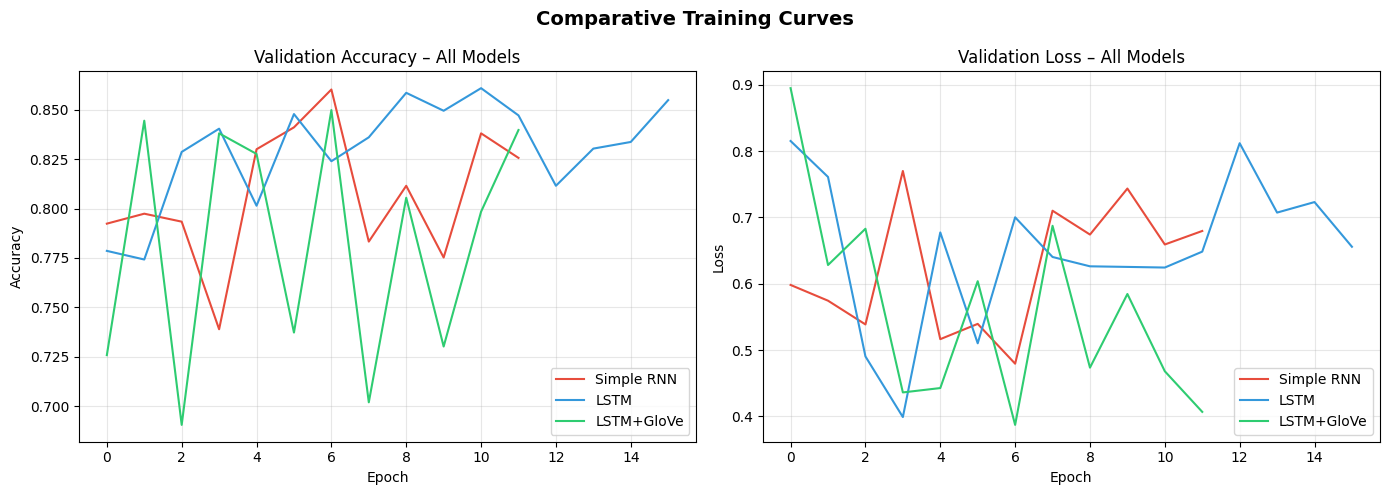

In [29]:
# ── OVERLAY LEARNING CURVES ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for hist, name, col in [(history1, 'Simple RNN', '#e74c3c'),
                         (history2, 'LSTM',       '#3498db'),
                         (history3, 'LSTM+GloVe', '#2ecc71')]:
    axes[0].plot(hist.history['val_accuracy'], label=name, color=col)
    axes[1].plot(hist.history['val_loss'],     label=name, color=col)

axes[0].set_title('Validation Accuracy – All Models')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title('Validation Loss – All Models')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Comparative Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparative_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# ── SUMMARY TABLE ─────────────────────────────────────────────────────────────
summary_df = pd.DataFrame({
    'Model'          : model_names,
    'Test Accuracy'  : [f'{a:.4f} ({a*100:.2f}%)' for a in accuracies],
    'Train Time (s)' : [f'{t:.1f}' for t in times_sec]
})
print("\n=== Model Performance Summary ===")
print(summary_df.to_string(index=False))


=== Model Performance Summary ===
       Model   Test Accuracy Train Time (s)
  Simple RNN 0.8607 (86.07%)           21.6
        LSTM 0.8631 (86.31%)           49.3
LSTM + GloVe 0.8587 (85.87%)           33.8


## 9. Error Analysis

In [31]:
# ── MISCLASSIFIED SAMPLE TWEETS ───────────────────────────────────────────────
best_pred = pred3
best_true = true3

wrong_idx = np.where(best_pred != best_true)[0]
print(f"Total misclassified: {len(wrong_idx):,} / {len(best_true):,} "
      f"({len(wrong_idx)/len(best_true)*100:.1f}%)")

print("\n=== Sample Misclassified Tweets (Model 3 – LSTM + GloVe) ===")
for i in wrong_idx[:5]:
    true_label = label_name_map.get(le.classes_[best_true[i]], str(le.classes_[best_true[i]]))
    pred_label = label_name_map.get(le.classes_[best_pred[i]], str(le.classes_[best_pred[i]]))
    print(f"  Original  : {X_test_text[i][:100]}")
    print(f"  True Label: {true_label}")
    print(f"  Predicted : {pred_label}")
    print()

Total misclassified: 700 / 4,953 (14.1%)

=== Sample Misclassified Tweets (Model 3 – LSTM + GloVe) ===
  Original  : stop trying honky
  True Label: offensive language
  Predicted : hate speec

  Original  : like tattoo head form mullet white trash people entertaining sometimes
  True Label: offensive language
  Predicted : neither

  Original  : hungry ferkin nip
  True Label: offensive language
  Predicted : neither

  Original  : nigga nap fuck bitch mean lame fuckin lame deez nigga corny asl
  True Label: offensive language
  Predicted : hate speec

  Original  : gansitos atg beaner candy
  True Label: offensive language
  Predicted : hate speec



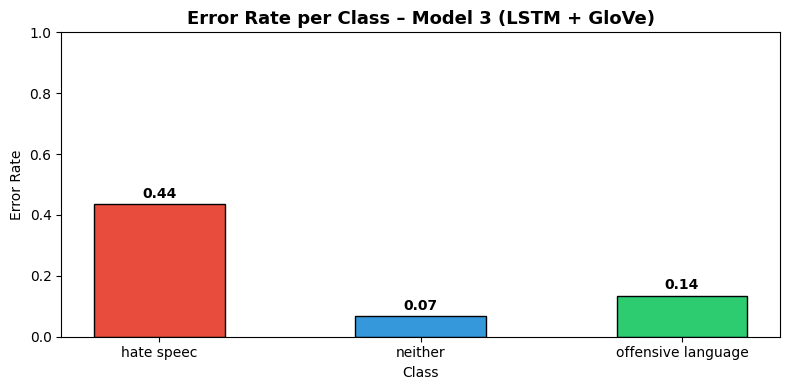

In [44]:
# ── ERROR RATE PER CLASS ──────────────────────────────────────────────────────
error_df = pd.DataFrame({'true': best_true, 'pred': best_pred})
error_by_class = error_df[error_df['true'] != error_df['pred']].groupby('true').size()
total_by_class = error_df.groupby('true').size()
error_rate     = (error_by_class / total_by_class).fillna(0)

readable_class_names = [label_name_map.get(le.classes_[i], str(le.classes_[i]))
                        for i in error_rate.index]

plt.figure(figsize=(8, 4))
plt.bar(readable_class_names, error_rate.values,
        color=bar_colors[:len(error_rate)], edgecolor='black', width=0.5)
plt.title('Error Rate per Class – Model 3 (LSTM + GloVe)', fontsize=13, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Error Rate')
plt.ylim(0, 1.0)
for i, v in enumerate(error_rate.values):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()



In [45]:
print("\nObservation: Higher error rates on minority classes (e.g., Hate Speech)")
print("are expected due to dataset imbalance, even with class weighting.")


Observation: Higher error rates on minority classes (e.g., Hate Speech)
are expected due to dataset imbalance, even with class weighting.


## 10. GUI – Real-Time Prediction (Gradio)

In [46]:
# ── GRADIO INTERFACE ──────────────────────────────────────────────────────────

import gradio as gr

# Function for prediction
def predict_hate_speech(tweet_text):

    # Check if input is empty
    if not tweet_text.strip():
        return "⚠️ Please enter a tweet."

    # Clean and preprocess text
    cleaned = clean_text(tweet_text)

    # Convert text into sequence
    seq = tokenizer.texts_to_sequences([cleaned])

    # Pad sequence to fixed length
    padded = pad_sequences(
        seq,
        maxlen=MAX_LEN,
        padding='post',
        truncating='post'
    )

    # Predict probabilities
    probs = model3.predict(padded, verbose=0)[0]

    # Get predicted class
    predicted_idx = int(np.argmax(probs))

    # Convert encoded label to readable label
    predicted_class = label_name_map.get(
        le.classes_[predicted_idx],
        str(le.classes_[predicted_idx])
    )

    # Highest confidence score
    confidence = float(np.max(probs))

    # Create formatted output
    output = f"✅ Prediction : {predicted_class}\n"
    output += f"📊 Confidence : {confidence:.2%}\n\n"
    output += "🔍 All Probabilities:\n\n"

    # Show probability for each class
    for i, p in enumerate(probs):
        cls_name = label_name_map.get(
            le.classes_[i],
            str(le.classes_[i])
        )
        output += f"• {cls_name}: {p:.2%}\n"

    return output


# Custom UI Theme
custom_css = """
body {
    background-color: #f5f7fa;
}

.gradio-container {
    font-family: Arial, sans-serif;
}

textarea {
    font-size: 16px !important;
}

footer {
    display: none !important;
}
"""


# Create Gradio interface
demo = gr.Interface(
    fn=predict_hate_speech,

    inputs=gr.Textbox(
        lines=4,
        placeholder="Type or paste a tweet here...",
        label="📝 Tweet Input"
    ),

    outputs=gr.Textbox(
        label="🤖 Prediction Result"
    ),

    title="🚨 Hate Speech Detection System",

    description="""
    This AI model classifies tweets into:
    • Hate Speech
    • Offensive Language
    • Neither

    Built using Bi-LSTM + GloVe Embeddings.
    """,

    examples=[
        ["I love all people and believe in equality!"],
        ["RT @user: This is a great day for everyone"],
        ["This is terrible behavior from those involved"],
    ],

    theme=gr.themes.Soft(),
    css=custom_css
)

# Launch app with public share link
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7edb048658e1955fca.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 11. Save Models

In [34]:
# ── SAVE ALL MODELS (native Keras format – no warnings) ──────────────────────
model1.save('model1_simplernn.keras')
model2.save('model2_lstm.keras')
model3.save('model3_lstm_glove.keras')

import pickle
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("All models and tokenizer saved.")
print("  model1_simplernn.keras")
print("  model2_lstm.keras")
print("  model3_lstm_glove.keras")
print("  tokenizer.pkl")
print("  label_encoder.pkl")

All models and tokenizer saved.
  model1_simplernn.keras
  model2_lstm.keras
  model3_lstm_glove.keras
  tokenizer.pkl
  label_encoder.pkl
